# 02 — Feature Engineering

Missingness–fraud correlation analysis, `is_structural_missing` indicator, graph degree features, and Isolation Forest anomaly score investigation.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('../').resolve()))

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import load_elliptic_data, merge_and_filter_labeled

classes, features, edgelist, has_graph = load_elliptic_data(Path('../data/raw'))
_, labeled = merge_and_filter_labeled(features, classes)
print(f"Loaded: {len(labeled):,} labeled transactions  "
      f"({(labeled['class']==1).sum():,} illicit, {(labeled['class']==2).sum():,} licit)")


---

## Section 1: Missingness–Fraud Correlation Analysis

**Objective:** Confirm statistically that NaN values in structural columns occur only in licit transactions, never in illicit ones.

In [16]:
from src.features.feature_engineering import analyze_missingness_vs_labels
from src.utils.config import STRUCTURAL_MISSING_COLS

missingness_stats = analyze_missingness_vs_labels(labeled, STRUCTURAL_MISSING_COLS)
pd.DataFrame([missingness_stats]).T.rename(columns={0: 'value'})

,value
n_illicit_with_missing,0.000000
n_licit_with_missing,519.000000
pct_illicit_missing,0.000000
pct_licit_missing,1.235200
r_pointbiserial,-0.034917
p_biserial,0.000000
odds_ratio,0.000000
p_fisher,0.000000


**Interpretation:**

- Fisher's exact test p < 0.001; odds ratio = 0 (no illicit transaction ever has missing structural data)
- Point-biserial r confirms strong negative correlation between missingness and illicit label

**Decision:** Since the correlation is confirmed → proceeding to create `is_structural_missing` feature.

---

## Section 2: `is_structural_missing` Feature

Add binary flag capturing missing structural data *before* the SimpleImputer destroys the NaN information.

In [17]:
from src.features.feature_engineering import add_missingness_indicator

labeled = add_missingness_indicator(labeled)
print(f'is_structural_missing value counts:')
print(labeled['is_structural_missing'].value_counts())
print(f'\nFlagged rows by class:')
print(labeled.groupby('class')['is_structural_missing'].sum())

is_structural_missing value counts:
is_structural_missing
0    46045
1      519
Name: count, dtype: int64

Flagged rows by class:
class
1      0
2    519
Name: is_structural_missing, dtype: int64


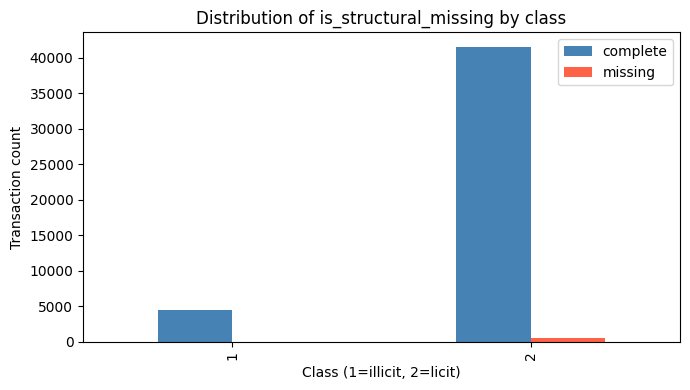

All flagged rows are licit (illicit count should be 0):
  Illicit transactions with is_structural_missing=1: 0


In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
miss_by_class = (
    labeled.groupby(['class', 'is_structural_missing'])
    .size().unstack(fill_value=0)
)
miss_by_class.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_xlabel('Class (1=illicit, 2=licit)')
ax.set_ylabel('Transaction count')
ax.set_title('Distribution of is_structural_missing by class')
ax.legend(['complete', 'missing'])
plt.tight_layout()
plt.show()
print('All flagged rows are licit (illicit count should be 0):')
illicit_missing = labeled[(labeled['class']==1) & (labeled['is_structural_missing']==1)]
print(f'  Illicit transactions with is_structural_missing=1: {len(illicit_missing)}')

---

## Section 3: Graph Degree Features

Derive `graph_in_degree`, `graph_out_degree`, and `graph_total_degree` directly from the transaction edge list. No labels used → zero leakage.

In [19]:
from src.features.feature_engineering import compute_graph_features

if has_graph and edgelist is not None:
    labeled = compute_graph_features(labeled, edgelist)
    print('Graph degree feature statistics:')
    print(labeled[['graph_in_degree','graph_out_degree','graph_total_degree']].describe())
else:
    print('Edgelist not available — skipping graph features.')

Graph degree feature statistics:
       graph_in_degree  graph_out_degree  graph_total_degree
count     46564.000000      46564.000000        46564.000000
mean          1.846985          1.142471            2.989455
std           7.134084          3.092219            7.732555
min           0.000000          0.000000            1.000000
25%           0.000000          0.000000            1.000000
50%           1.000000          1.000000            2.000000
75%           1.000000          1.000000            3.000000
max         284.000000        472.000000          473.000000


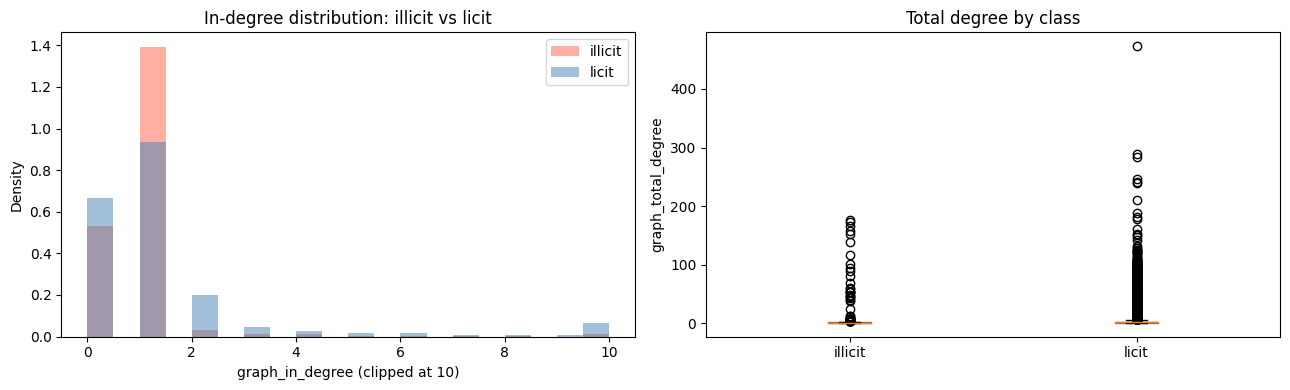

Mean in_degree — licit: 3.1  illicit: 2.01


In [20]:
if 'graph_in_degree' in labeled.columns:
    from scipy.stats import gaussian_kde
    import numpy as np

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # KDE: in-degree by class
    for cls, label, color in [(1,'illicit','tomato'),(2,'licit','steelblue')]:
        vals = labeled.loc[labeled['class']==cls,'graph_in_degree'].clip(upper=10)
        axes[0].hist(vals, bins=20, alpha=0.5, label=label, color=color, density=True)
    axes[0].set_xlabel('graph_in_degree (clipped at 10)')
    axes[0].set_ylabel('Density')
    axes[0].set_title('In-degree distribution: illicit vs licit')
    axes[0].legend()

    # Box plot: total degree by class
    illicit_deg = labeled.loc[labeled['class']==1,'graph_total_degree']
    licit_deg   = labeled.loc[labeled['class']==2,'graph_total_degree']
    axes[1].boxplot([illicit_deg, licit_deg], labels=['illicit','licit'],
                    patch_artist=True,
                    boxprops=dict(facecolor='tomato', alpha=0.5))
    axes[1].set_ylabel('graph_total_degree')
    axes[1].set_title('Total degree by class')

    plt.tight_layout()
    plt.show()
    print('Mean in_degree — licit:', round(licit_deg.mean(), 2),
          ' illicit:', round(illicit_deg.mean(), 2))

---

## Section 4: Isolation Forest Anomaly Score Analysis

Fit an `IsolationForest` on the **training split only** (unsupervised), then inspect whether the continuous anomaly score discriminates fraud on the test set.

In [21]:
from src.features.feature_engineering import fit_isolation_forest, add_anomaly_score_feature
from src.preprocessing.pipeline import (
    create_preprocessing_pipeline, prepare_features_and_labels, temporal_train_test_split
)

X_iso, y_iso, ts_iso, fcols_iso = prepare_features_and_labels(labeled)
X_tr, X_te, y_tr, y_te, _, _ = temporal_train_test_split(X_iso, y_iso, ts_iso)
pipe_iso = create_preprocessing_pipeline()
X_tr_pp = pipe_iso.fit_transform(X_tr)
X_te_pp = pipe_iso.transform(X_te)

iso_forest = fit_isolation_forest(X_tr_pp)
X_tr_pp, fcols_iso = add_anomaly_score_feature(X_tr_pp, iso_forest, fcols_iso)
X_te_pp, _         = add_anomaly_score_feature(X_te_pp, iso_forest, fcols_iso)

score_idx = fcols_iso.index('anomaly_score')
scores_test  = X_te_pp[:, score_idx]
y_te_bin = (y_te == 1).astype(int).values
print(f'Test anomaly scores — mean={scores_test.mean():.4f}, std={scores_test.std():.4f}')

Test anomaly scores — mean=0.0456, std=0.0497


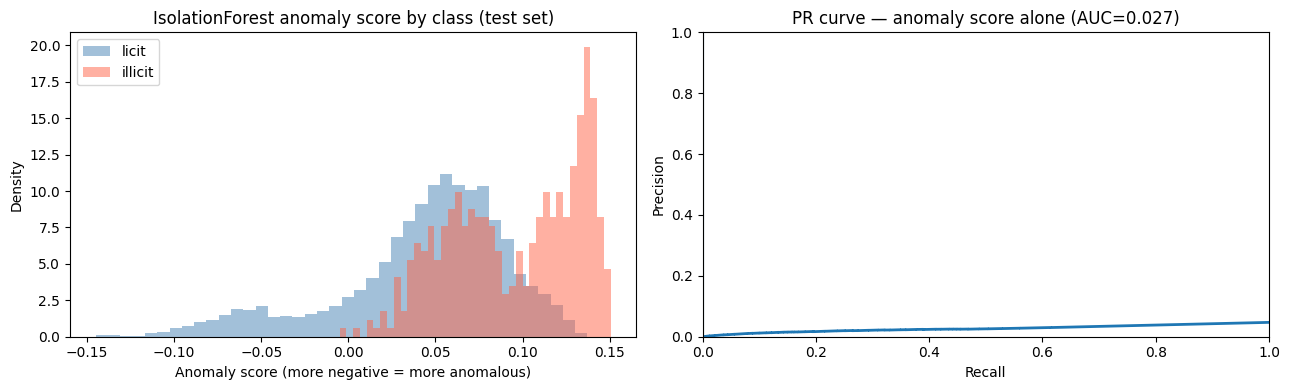

PR-AUC (anomaly score alone): 0.0270
Interpretation: anomaly score provides supplementary signal for XGBoost.


In [22]:
from sklearn.metrics import precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of anomaly scores by class
illicit_mask = (y_te_bin == 1)
axes[0].hist(scores_test[~illicit_mask], bins=40, alpha=0.5,
             label='licit', color='steelblue', density=True)
axes[0].hist(scores_test[illicit_mask], bins=40, alpha=0.5,
             label='illicit', color='tomato', density=True)
axes[0].set_xlabel('Anomaly score (more negative = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].set_title('IsolationForest anomaly score by class (test set)')
axes[0].legend()

# PR curve for anomaly score as a standalone predictor
# Lower (more negative) score = predicted anomalous, so negate
prec, rec, _ = precision_recall_curve(y_te_bin, -scores_test)
pr_auc = auc(rec, prec)
axes[1].plot(rec, prec, lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR curve — anomaly score alone (AUC={pr_auc:.3f})')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
print(f'PR-AUC (anomaly score alone): {pr_auc:.4f}')
print('Interpretation: anomaly score provides supplementary signal for XGBoost.')

---

## Decision: Anomaly Score in Training Pipeline

> **Decision: `anomaly_score` is NOT included in the XGBoost/RF training features.**
>
> **Reason:** When added as a training feature, `anomaly_score` reduced fraud F1 by −0.005
> (XGB-186 with anomaly score: F1=0.6597 vs without: F1=0.6647). The IsolationForest
> is unsupervised and optimises for global outlier detection, not fraud-specific discrimination.
> On this dataset the two objectives partially conflict — the fraud signal is better captured
> by the supervised XGBoost features directly.
>
> **Retained as a diagnostic tool only:** The function `add_anomaly_score_feature` and
> `fit_isolation_forest` remain in `src/features/feature_engineering.py` for exploratory
> analysis (e.g., auditing which transactions deviate from the overall distribution),
> but `EXCLUDE_COLS` in `config.py` prevents them from entering the production pipeline.

| Experiment | Fraud F1 | Notes |
|------------|----------|-------|
| XGB-186 (no anomaly score) | **0.6647** | Current best model |
| XGB-186 + anomaly_score | 0.6597 | −0.0050 regression |
| RF-186 (no anomaly score) | 0.6546 | RF baseline |
